In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, auc, ConfusionMatrixDisplay
)

# Consistent style
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#333355',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'text.color': '#e0e0e0',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

SEED = 42
np.random.seed(SEED)
print("Libraries loaded.")

Libraries loaded.


### Experiment 1 -  balanced dataset: all metrics agree

In [4]:
# ----- Balanced dataset (50:50) -----
X_bal, y_bal = make_classification(
    n_samples=2000, n_features=20, n_informative=15,
    n_redundant=5, weights=[0.5, 0.5], random_state=SEED
)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bal, y_bal, test_size=0.25, random_state=SEED
)

lr_bal = LogisticRegression(max_iter=1000, random_state=SEED)
lr_bal.fit(X_train_b, y_train_b)
y_pred_b = lr_bal.predict(X_test_b)

print("=" * 55)
print("BALANCED DATASET — Logistic Regression @ threshold 0.5")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_test_b, y_pred_b):.4f}")
print(f"  Precision : {precision_score(y_test_b, y_pred_b):.4f}")
print(f"  Recall    : {recall_score(y_test_b, y_pred_b):.4f}")
print(f"  F1        : {f1_score(y_test_b, y_pred_b):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test_b, y_pred_b, target_names=["Non-Fraud", "Fraud"]))

BALANCED DATASET — Logistic Regression @ threshold 0.5
  Accuracy  : 0.8160
  Precision : 0.8147
  Recall    : 0.7941
  F1        : 0.8043

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.82      0.84      0.83       262
       Fraud       0.81      0.79      0.80       238

    accuracy                           0.82       500
   macro avg       0.82      0.81      0.82       500
weighted avg       0.82      0.82      0.82       500



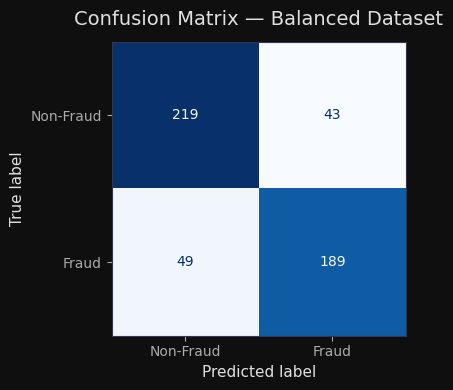


Observation: On balanced data, all four metrics tell the same story.
Accuracy is a perfectly reliable summary when classes are balanced.


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
cm_b = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=["Non-Fraud", "Fraud"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Balanced Dataset", pad=12)
plt.tight_layout()
plt.savefig("confusion_balanced.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nObservation: On balanced data, all four metrics tell the same story.")
print("Accuracy is a perfectly reliable summary when classes are balanced.")


### Experiment 2 - imbalanced dataset: accuracy lies, F1 exposes it

Now we flip the same experiment. Same model, same code — but the dataset is 95% class 0 and 5% class 1.


In [6]:
# ----- Imbalanced dataset (95:5) -----
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=20, n_informative=15,
    n_redundant=5, weights=[0.95, 0.05], flip_y=0, random_state=SEED
)

print(f"Class distribution — 0: {sum(y_imb==0)}  |  1: {sum(y_imb==1)}")
print(f"Minority class is {sum(y_imb==1)/len(y_imb)*100:.1f}% of data")

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=SEED, stratify=y_imb
)

lr_imb = LogisticRegression(max_iter=1000, random_state=SEED)
lr_imb.fit(X_train_i, y_train_i)
y_pred_i = lr_imb.predict(X_test_i)

print()
print("=" * 57)
print("IMBALANCED DATASET (95:5) — Logistic Regression @ threshold 0.5")
print("=" * 57)
print(f"  Accuracy  : {accuracy_score(y_test_i, y_pred_i):.4f}  ← looks great")
print(f"  Precision : {precision_score(y_test_i, y_pred_i, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test_i, y_pred_i, zero_division=0):.4f}  ← near zero")
print(f"  F1        : {f1_score(y_test_i, y_pred_i, zero_division=0):.4f}  ← exposes the failure")
print()
print("Classification Report:")
print(classification_report(y_test_i, y_pred_i, target_names=["Non-Fraud", "Fraud"], zero_division=0))

Class distribution — 0: 1900  |  1: 100
Minority class is 5.0% of data

IMBALANCED DATASET (95:5) — Logistic Regression @ threshold 0.5
  Accuracy  : 0.9640  ← looks great
  Precision : 0.8889
  Recall    : 0.3200  ← near zero
  F1        : 0.4706  ← exposes the failure

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.97      1.00      0.98       475
       Fraud       0.89      0.32      0.47        25

    accuracy                           0.96       500
   macro avg       0.93      0.66      0.73       500
weighted avg       0.96      0.96      0.96       500



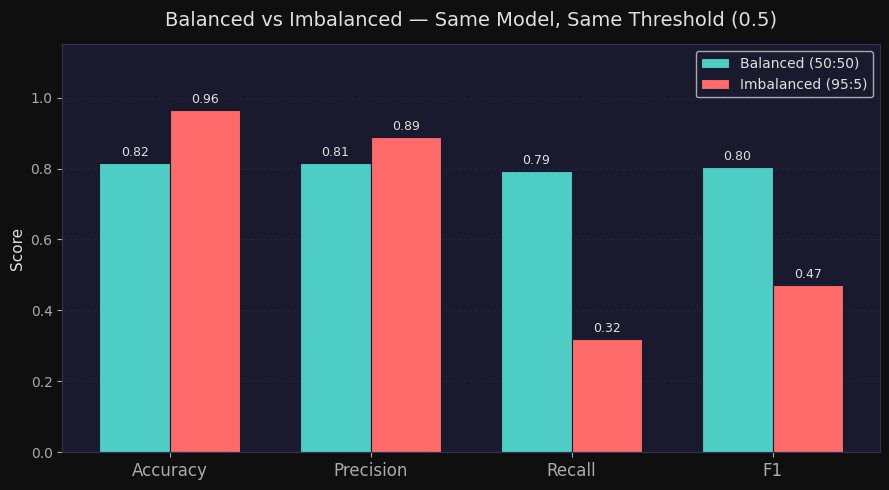


Key takeaway:
Accuracy barely changes (balanced ~0.88, imbalanced ~0.95).
Recall and F1 collapse to near zero on imbalanced data.
Accuracy rewarded the model for ignoring the minority class.


In [7]:
# Side-by-side metric comparison: balanced vs imbalanced
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

bal_scores = [
    accuracy_score(y_test_b, y_pred_b),
    precision_score(y_test_b, y_pred_b),
    recall_score(y_test_b, y_pred_b),
    f1_score(y_test_b, y_pred_b)
]

imb_scores = [
    accuracy_score(y_test_i, y_pred_i),
    precision_score(y_test_i, y_pred_i, zero_division=0),
    recall_score(y_test_i, y_pred_i, zero_division=0),
    f1_score(y_test_i, y_pred_i, zero_division=0)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, bal_scores, width, label='Balanced (50:50)',
               color='#4ecdc4', edgecolor='#1a1a2e', linewidth=0.8)
bars2 = ax.bar(x + width/2, imb_scores, width, label='Imbalanced (95:5)',
               color='#ff6b6b', edgecolor='#1a1a2e', linewidth=0.8)

ax.set_ylabel('Score')
ax.set_title('Balanced vs Imbalanced — Same Model, Same Threshold (0.5)', pad=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9, color='#e0e0e0')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9, color='#e0e0e0')

plt.tight_layout()
plt.savefig("balanced_vs_imbalanced.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nKey takeaway:")
print("Accuracy barely changes (balanced ~0.88, imbalanced ~0.95).")
print("Recall and F1 collapse to near zero on imbalanced data.")
print("Accuracy rewarded the model for ignoring the minority class.")

### Experiment 3 - threshold sweep: same model, different story

A classification model doesn't natively output 0 or 1. It outputs a probability. The **threshold** is the line we draw.

Default threshold = 0.5. But there's nothing special about 0.5.

Lowering the threshold makes the model more aggressive about flagging positives:
- More positives predicted → Recall ↑, Precision ↓

Raising the threshold makes the model more conservative:
- Fewer positives predicted → Precision ↑, Recall ↓

Let's watch this happen on the imbalanced dataset.

In [8]:
# Get probabilities from the imbalanced LR model
y_proba_i = lr_imb.predict_proba(X_test_i)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)

results = []
for thresh in thresholds:
    y_pred_t = (y_proba_i >= thresh).astype(int)
    results.append({
        'threshold': thresh,
        'accuracy': accuracy_score(y_test_i, y_pred_t),
        'precision': precision_score(y_test_i, y_pred_t, zero_division=0),
        'recall': recall_score(y_test_i, y_pred_t, zero_division=0),
        'f1': f1_score(y_test_i, y_pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(results)

# Print a clean summary table
print("Threshold | Accuracy | Precision | Recall  | F1")
print("-" * 55)
for _, row in df_thresh.iterrows():
    print(f"  {row.threshold:.2f}    |  {row.accuracy:.3f}   |  {row.precision:.3f}    | {row.recall:.3f}  | {row.f1:.3f}")

Threshold | Accuracy | Precision | Recall  | F1
-------------------------------------------------------
  0.10    |  0.904   |  0.333    | 0.920  | 0.489
  0.15    |  0.934   |  0.409    | 0.720  | 0.522
  0.20    |  0.944   |  0.457    | 0.640  | 0.533
  0.25    |  0.958   |  0.583    | 0.560  | 0.571
  0.30    |  0.968   |  0.800    | 0.480  | 0.600
  0.35    |  0.968   |  0.846    | 0.440  | 0.579
  0.40    |  0.968   |  0.909    | 0.400  | 0.556
  0.45    |  0.966   |  0.900    | 0.360  | 0.514
  0.50    |  0.964   |  0.889    | 0.320  | 0.471
  0.55    |  0.964   |  0.889    | 0.320  | 0.471
  0.60    |  0.964   |  0.889    | 0.320  | 0.471
  0.65    |  0.962   |  0.875    | 0.280  | 0.424
  0.70    |  0.960   |  0.857    | 0.240  | 0.375
  0.75    |  0.956   |  0.800    | 0.160  | 0.267
  0.80    |  0.958   |  1.000    | 0.160  | 0.276
  0.85    |  0.956   |  1.000    | 0.120  | 0.214
  0.90    |  0.956   |  1.000    | 0.120  | 0.214


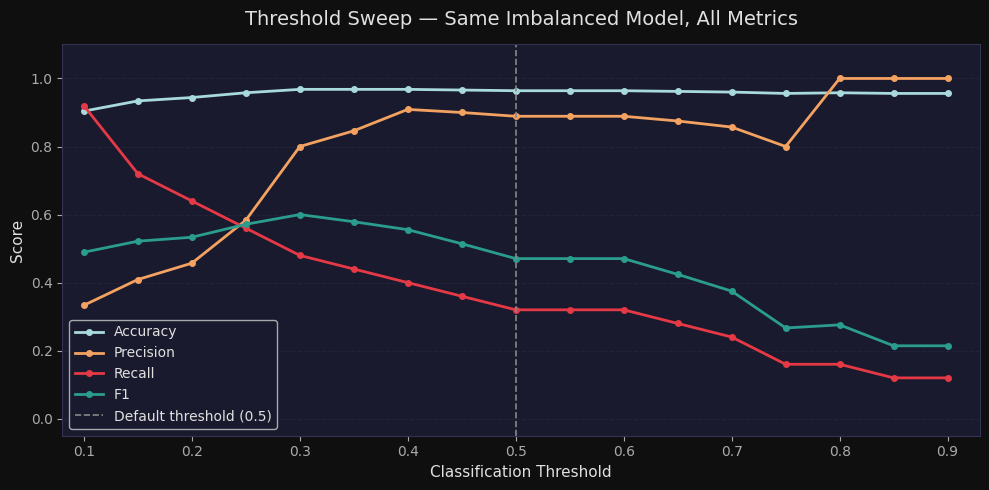


Key takeaway:
The model didn't change. Only the threshold changed.
At 0.5, Recall is near 0. At 0.3, Recall improves significantly.
Precision and Recall always trade off. F1 finds the balance point.
The 'best' threshold depends on which mistake costs more.


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

palette = {'accuracy': '#a8dadc', 'precision': '#f4a261', 'recall': '#e63946', 'f1': '#2a9d8f'}

for metric, color in palette.items():
    ax.plot(df_thresh['threshold'], df_thresh[metric], marker='o', markersize=4,
            label=metric.capitalize(), color=color, linewidth=2)

ax.axvline(x=0.5, color='#888888', linestyle='--', linewidth=1.2, label='Default threshold (0.5)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sweep — Same Imbalanced Model, All Metrics', pad=14)
ax.legend(fontsize=10)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.set_xlim(0.08, 0.93)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig("threshold_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nKey takeaway:")
print("The model didn't change. Only the threshold changed.")
print("At 0.5, Recall is near 0. At 0.3, Recall improves significantly.")
print("Precision and Recall always trade off. F1 finds the balance point.")
print("The 'best' threshold depends on which mistake costs more.")

### Experiment 4 - random forest + threshold tuning on imbalanced data

Now we bring in a stronger model. Random Forest on the same imbalanced dataset with class weights enabled, then tune the threshold.

In [10]:
rf_imb = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_imb.fit(X_train_i, y_train_i)
y_proba_rf = rf_imb.predict_proba(X_test_i)[:, 1]

# Compare LR vs RF at multiple thresholds
comparison_thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

print("Model Comparison at Different Thresholds (Imbalanced 95:5 Dataset)")
print("=" * 70)
print(f"{'Threshold':>10} | {'Model':>20} | {'Accuracy':>9} | {'Recall':>7} | {'F1':>7}")
print("-" * 70)

for thresh in comparison_thresholds:
    lr_pred = (y_proba_i >= thresh).astype(int)
    rf_pred = (y_proba_rf >= thresh).astype(int)
    print(f"  {thresh:.1f}       | {'Logistic Regression':>20} | {accuracy_score(y_test_i, lr_pred):>9.3f} | {recall_score(y_test_i, lr_pred, zero_division=0):>7.3f} | {f1_score(y_test_i, lr_pred, zero_division=0):>7.3f}")
    print(f"           | {'Random Forest':>20} | {accuracy_score(y_test_i, rf_pred):>9.3f} | {recall_score(y_test_i, rf_pred, zero_division=0):>7.3f} | {f1_score(y_test_i, rf_pred, zero_division=0):>7.3f}")
    print("-" * 70)

Model Comparison at Different Thresholds (Imbalanced 95:5 Dataset)
 Threshold |                Model |  Accuracy |  Recall |      F1
----------------------------------------------------------------------
  0.2       |  Logistic Regression |     0.944 |   0.640 |   0.533
           |        Random Forest |     0.972 |   0.560 |   0.667
----------------------------------------------------------------------
  0.3       |  Logistic Regression |     0.968 |   0.480 |   0.600
           |        Random Forest |     0.970 |   0.400 |   0.571
----------------------------------------------------------------------
  0.4       |  Logistic Regression |     0.968 |   0.400 |   0.556
           |        Random Forest |     0.960 |   0.200 |   0.333
----------------------------------------------------------------------
  0.5       |  Logistic Regression |     0.964 |   0.320 |   0.471
           |        Random Forest |     0.956 |   0.120 |   0.214
---------------------------------------------------

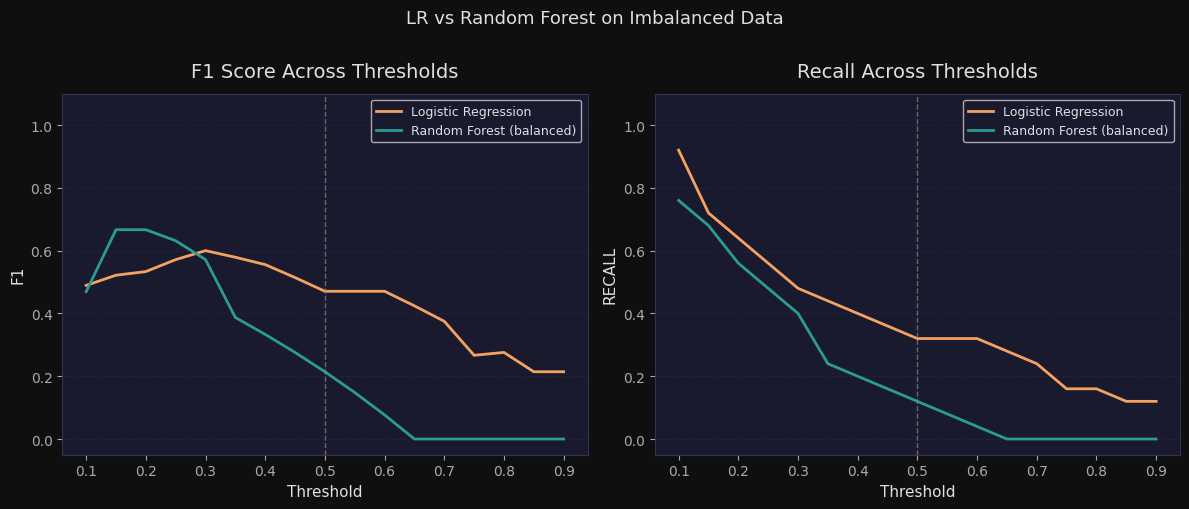


Key takeaway:
Random Forest with class_weight='balanced' dramatically improves F1 and Recall.
Both model selection and threshold tuning are active design decisions.


In [11]:
# F1 curve — LR vs RF across full threshold range
rf_results = []
for thresh in thresholds:
    y_pred_rf_t = (y_proba_rf >= thresh).astype(int)
    rf_results.append({
        'threshold': thresh,
        'f1': f1_score(y_test_i, y_pred_rf_t, zero_division=0),
        'recall': recall_score(y_test_i, y_pred_rf_t, zero_division=0),
    })

df_rf = pd.DataFrame(rf_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, title in zip(axes, ['f1', 'recall'], ['F1 Score', 'Recall']):
    ax.plot(df_thresh['threshold'], df_thresh[metric], color='#f4a261', linewidth=2, label='Logistic Regression')
    ax.plot(df_rf['threshold'], df_rf[metric], color='#2a9d8f', linewidth=2, label='Random Forest (balanced)')
    ax.axvline(x=0.5, color='#888888', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{title} Across Thresholds', pad=12)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.set_ylim(-0.05, 1.1)

fig.suptitle('LR vs Random Forest on Imbalanced Data', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("lr_vs_rf_threshold.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nKey takeaway:")
print("Random Forest with class_weight='balanced' dramatically improves F1 and Recall.")
print("Both model selection and threshold tuning are active design decisions.")

### Part 9 - macro vs weighted F1 in multiclass

So far we've dealt with binary classification. In multiclass settings, F1 must be summarized across all classes. Two common strategies:

- **Macro F1**: Each class gets equal weight regardless of sample count. A rare class failing pulls the score down.
- **Weighted F1**: Each class is weighted by its sample count. Good performance on the majority class dominates.

Use **macro** when every class matters equally — rare disease detection, safety-critical defect categories.
Use **weighted** when majority class frequency should influence the aggregate score.

In [12]:
# Simulate a 4-class problem with imbalanced classes
X_mc, y_mc = make_classification(
    n_samples=2000, n_features=20, n_informative=12,
    n_classes=4, n_clusters_per_class=1,
    weights=[0.6, 0.2, 0.15, 0.05],
    random_state=SEED
)

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_mc, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc
)

lr_mc = LogisticRegression(max_iter=1000, random_state=SEED)
lr_mc.fit(X_train_mc, y_train_mc)
y_pred_mc = lr_mc.predict(X_test_mc)

macro_f1 = f1_score(y_test_mc, y_pred_mc, average='macro')
weighted_f1 = f1_score(y_test_mc, y_pred_mc, average='weighted')
accuracy_mc = accuracy_score(y_test_mc, y_pred_mc)

print("4-Class Imbalanced Dataset (60:20:15:5 split)")
print("=" * 45)
print(f"  Accuracy    : {accuracy_mc:.4f}")
print(f"  Macro F1    : {macro_f1:.4f}  ← penalizes minority class failure")
print(f"  Weighted F1 : {weighted_f1:.4f}  ← dominated by majority class")
print()
print(classification_report(y_test_mc, y_pred_mc, target_names=['Class A', 'Class B', 'Class C', 'Class D']))

4-Class Imbalanced Dataset (60:20:15:5 split)
  Accuracy    : 0.8420
  Macro F1    : 0.7363  ← penalizes minority class failure
  Weighted F1 : 0.8386  ← dominated by majority class

              precision    recall  f1-score   support

     Class A       0.89      0.91      0.90       299
     Class B       0.78      0.79      0.78       101
     Class C       0.79      0.77      0.78        75
     Class D       0.59      0.40      0.48        25

    accuracy                           0.84       500
   macro avg       0.76      0.72      0.74       500
weighted avg       0.84      0.84      0.84       500



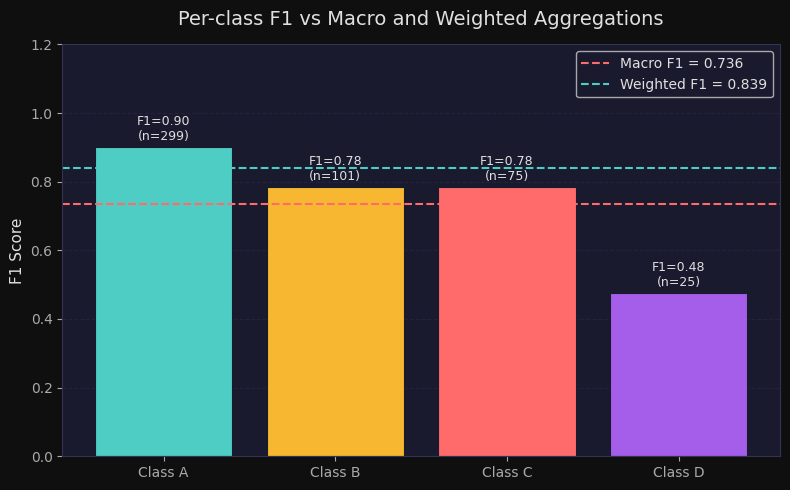

In [13]:
# Visualize per-class F1 scores
from sklearn.metrics import classification_report
report = classification_report(y_test_mc, y_pred_mc, output_dict=True)

classes = ['Class A', 'Class B', 'Class C', 'Class D']
class_keys = ['0', '1', '2', '3']
f1_per_class = [report[k]['f1-score'] for k in class_keys]
support = [report[k]['support'] for k in class_keys]

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#4ecdc4', '#f7b731', '#ff6b6b', '#a55eea']
bars = ax.bar(classes, f1_per_class, color=colors, edgecolor='#1a1a2e', linewidth=0.8)

for bar, sup, f1 in zip(bars, support, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'F1={f1:.2f}\n(n={int(sup)})', ha='center', fontsize=9, color='#e0e0e0')

ax.axhline(macro_f1, color='#ff6b6b', linestyle='--', linewidth=1.5, label=f'Macro F1 = {macro_f1:.3f}')
ax.axhline(weighted_f1, color='#4ecdc4', linestyle='--', linewidth=1.5, label=f'Weighted F1 = {weighted_f1:.3f}')

ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 vs Macro and Weighted Aggregations', pad=14)
ax.legend(fontsize=10)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.savefig("macro_vs_weighted_f1.png", dpi=150, bbox_inches='tight')
plt.show()


### Part 10 — PR curve vs ROC curve

Both curves visualize model performance across all thresholds. They tell different stories.

**ROC Curve** : plots True Positive Rate vs False Positive Rate.  
It can look optimistic when the negative class is huge, because a large TN count keeps the FPR low even when FP is not small in absolute terms.

**Precision-Recall Curve** : plots Precision vs Recall.  
It focuses entirely on the positive class. On highly imbalanced datasets, this gives a more honest picture of minority class performance.

> For highly imbalanced datasets, PR curves are often more informative than ROC curves because they focus on the minority class.

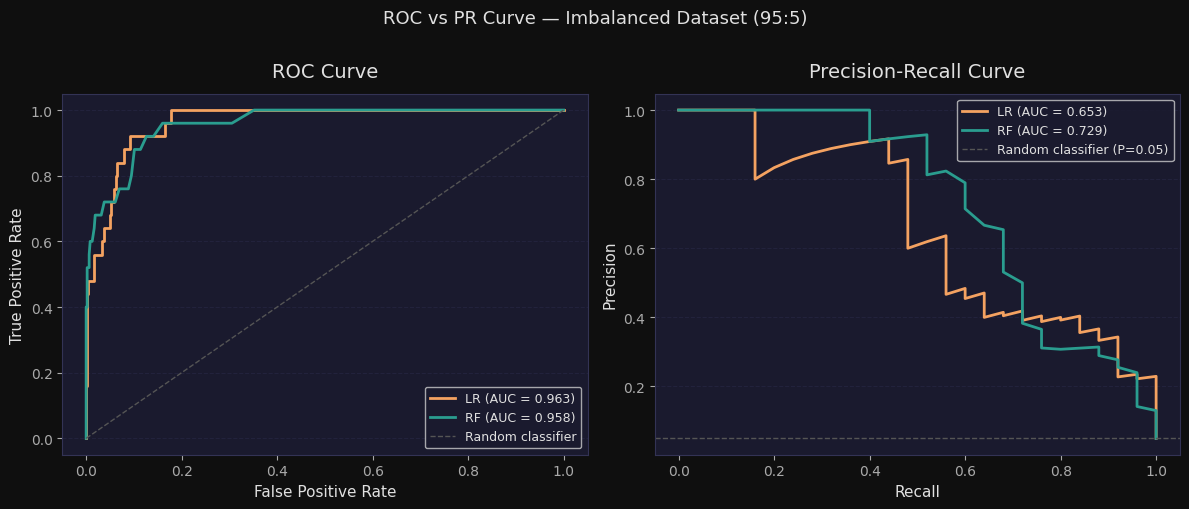


ROC AUC — LR: 0.963  |  RF: 0.958
PR  AUC — LR: 0.653  |  RF: 0.729

ROC AUC may look high even for a weak model on imbalanced data.
PR AUC is more discriminating — it focuses entirely on the positive class.


In [14]:
# PR and ROC curves for LR on imbalanced dataset
fpr, tpr, roc_thresholds = roc_curve(y_test_i, y_proba_i)
roc_auc_lr = auc(fpr, tpr)

precision_lr, recall_lr, pr_thresholds_lr = precision_recall_curve(y_test_i, y_proba_i)
pr_auc_lr = auc(recall_lr, precision_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test_i, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

precision_rf, recall_rf, _ = precision_recall_curve(y_test_i, y_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, color='#f4a261', linewidth=2, label=f'LR (AUC = {roc_auc_lr:.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='#2a9d8f', linewidth=2, label=f'RF (AUC = {roc_auc_rf:.3f})')
axes[0].plot([0, 1], [0, 1], color='#555555', linestyle='--', linewidth=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', pad=12)
axes[0].legend(fontsize=9)
axes[0].yaxis.grid(True)
axes[0].set_axisbelow(True)

# PR
axes[1].plot(recall_lr, precision_lr, color='#f4a261', linewidth=2, label=f'LR (AUC = {pr_auc_lr:.3f})')
axes[1].plot(recall_rf, precision_rf, color='#2a9d8f', linewidth=2, label=f'RF (AUC = {pr_auc_rf:.3f})')
baseline = sum(y_test_i) / len(y_test_i)
axes[1].axhline(baseline, color='#555555', linestyle='--', linewidth=1, label=f'Random classifier (P={baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', pad=12)
axes[1].legend(fontsize=9)
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)

fig.suptitle('ROC vs PR Curve — Imbalanced Dataset (95:5)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("roc_vs_pr_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC AUC — LR: {roc_auc_lr:.3f}  |  RF: {roc_auc_rf:.3f}")
print(f"PR  AUC — LR: {pr_auc_lr:.3f}  |  RF: {pr_auc_rf:.3f}")
print()
print("ROC AUC may look high even for a weak model on imbalanced data.")
print("PR AUC is more discriminating — it focuses entirely on the positive class.")